In [1]:
import numpy as np
import pandas as pd

In [2]:
model_df = pd.read_csv('team_stats_model_ready.csv')

In [32]:
X = model_df.drop(columns=["season", "team", "made_playoffs", "tp_PD","tp_SRS"])
y = model_df["made_playoffs"]

X

,off_yds_per_play,off_score_pct,off_turnover_pct,off_exp,off_pass_ANY/A,off_pass_TD%,off_pass_Int%,off_rush_Y/G,off_rush_EXP,def_yds_per_play,def_score_pct,def_turnover_pct,def_exp,def_pass_ANY/A,def_pass_Sk%,def_rush_Y/G,off_penalty_yds,def_penalty_yds
0,5.9,40.8,9.2,147.66,7.3,5.1,1.9,127.3,0.08,5.7,32.6,15.0,-17.25,5.8,4.7,112.7,744,838
1,5.3,28.3,12.5,-44.43,5.6,5.7,2.9,108.6,-17.41,6.1,39.9,14.2,-127.44,6.7,5.8,145.3,978,856
2,4.7,26.4,15.5,-96.90,3.7,2.6,4.6,124.0,-3.41,4.9,33.3,14.3,16.95,4.9,6.8,114.9,992,976
3,4.9,32.0,14.7,-97.61,4.8,3.4,3.6,101.4,-47.80,5.7,39.1,9.9,-70.75,6.5,6.3,126.3,948,817
4,5.3,40.7,10.7,81.02,6.0,3.2,1.6,152.6,28.17,4.8,29.1,9.5,30.09,5.2,6.9,82.9,940,1017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,5.0,33.0,13.1,-19.68,5.6,3.2,2.0,94.3,-22.25,4.8,40.2,11.2,4.59,5.8,8.4,120.6,920,913
252,5.9,45.9,14.2,80.50,7.3,5.2,3.1,123.3,-3.12,4.6,28.7,12.8,81.09,4.5,7.3,91.9,793,902
253,6.2,47.0,8.3,219.88,8.2,7.7,1.3,126.6,23.47,5.2,34.3,14.9,6.16,5.5,7.4,110.8,573,922
254,5.5,47.6,12.9,131.06,6.8,5.7,2.8,106.9,0.44,5.6,38.6,8.4,-115.46,7.1,3.3,107.8,651,734


## Logisitc Regression

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1818
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_pred = log_model.predict(X_test_scaled)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9230769230769231

Confusion Matrix
[[30  1]
 [ 3 18]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        31
           1       0.95      0.86      0.90        21

    accuracy                           0.92        52
   macro avg       0.93      0.91      0.92        52
weighted avg       0.92      0.92      0.92        52



In [39]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

             Feature  Coefficient
1      off_score_pct     0.816909
3            off_exp     0.760879
4     off_pass_ANY/A     0.460867
5       off_pass_TD%     0.446427
14      def_pass_Sk%     0.311276
11  def_turnover_pct     0.297409
8       off_rush_EXP     0.244621
12           def_exp     0.221430
7       off_rush_Y/G     0.214354
16   off_penalty_yds     0.008082
2   off_turnover_pct    -0.003534
17   def_penalty_yds    -0.025530
9   def_yds_per_play    -0.254304
15      def_rush_Y/G    -0.410472
13    def_pass_ANY/A    -0.438354
10     def_score_pct    -0.500949
6      off_pass_Int%    -0.712678
0   off_yds_per_play    -0.828805


In [40]:
results = model_df.loc[X_test.index, ["season", "team"]].copy()
results["actual"] = y_test
results["predicted"] = y_pred

print(results)

     season                  team  actual  predicted
186    2023       Atlanta Falcons       0          0
145    2022        Dallas Cowboys       1          1
66     2020  New England Patriots       0          0
40     2019        Houston Texans       1          0
119    2021      Baltimore Ravens       0          0
96     2021        Dallas Cowboys       1          1
123    2021  Jacksonville Jaguars       0          0
131    2022         New York Jets       0          0
106    2021       Atlanta Falcons       0          0
231    2025      Cleveland Browns       0          0
2      2018         Buffalo Bills       0          0
122    2021        Houston Texans       0          0
249    2025  Tampa Bay Buccaneers       0          0
103    2021         Detroit Lions       0          0
195    2024  New England Patriots       0          0
130    2022  New England Patriots       0          0
1      2018        Miami Dolphins       0          0
180    2023         Detroit Lions       1     

In [13]:
print(model_df["season"].unique())

[2018 2019 2020 2021 2022 2023 2024 2025]


In [41]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

kf = KFold(n_splits=5, shuffle=False)

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=kf)

print("Fold Accuracies:", scores)
print("Average Accuracy:", scores.mean())

Fold Accuracies: [0.88461538 0.92156863 0.80392157 0.88235294 0.82352941]
Average Accuracy: 0.8631975867269984


/Users/dylandellavalle/Documents/MDS/Capstone/nfl-decision-support-analytics/.conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/dylandellavalle/Documents/MDS/Capstone/nfl-decision-support-analytics/.conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (

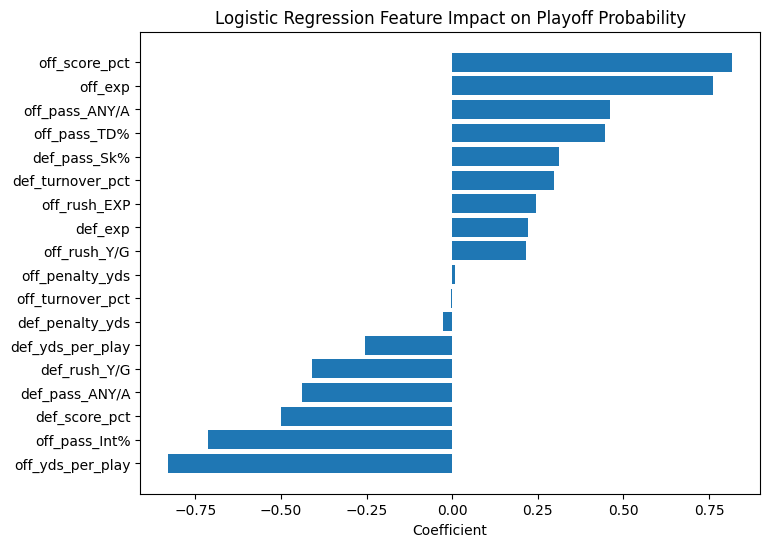

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Logistic Regression Feature Impact on Playoff Probability")
plt.xlabel("Coefficient")
plt.show()

## Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=2120
)

scores = cross_val_score(rf, X, y, cv=kf)

print("RF Fold Accuracies:", scores)
print("RF Average Accuracy:", scores.mean())

RF Fold Accuracies: [0.90384615 0.84313725 0.76470588 0.8627451  0.84313725]
RF Average Accuracy: 0.8435143288084465
